# Modeling Notebook
This notebook contains models for police searches carried out in San Diego using our target and outcome features from our previously wrangled data. The goal is to build models, starting with logistic regression and adding complexity as needed, to quantitatively understand and investigate search patterns across demographics, stop context, and neighborhood vulnerability.

Prerequisites: Run 0_data_wrangling.ipynb,
1_data_processing.ipynb, and
2_eda.ipynb first. This notebook reads in the final cleaned and merged dataset
produced during data wrangling and processing.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
import re
import sys
from pathlib import Path
REPO_ROOT = Path.cwd().parent.parent
sys.path.insert(0, str(REPO_ROOT))

from source.paths import RAW_DATA_PATH, INT_DATA_PATH, FINAL_DATA_PATH

## Data Integrity

Load data

In [4]:
df = pd.read_csv(FINAL_DATA_PATH / "post_eda_df.csv")

## Model Assumption Validation

### Logistic Regression

We need to address a couple of model assumptions to fit a binary logistic regression model.

1. **Binary outcome:** We ensured that `search_conducted` is binary earlier.
2. **Conditional independence of the outcome given the covariates:** This is likely false, since outcomes can be clustered by, for example, the officer conducting the stop. This is not one of our covariates and a limitation of our fit.
3. **Linearity of the log-odds in the continuous predictors:** (subject age, SVI index, hour of day).
4. **No perfect multicollinearity:** We will handle this by creating dummy variables for categorical predictors. We have already shown that the numeric predictors only have a small-moderate level of association.

We have already addressed most of these concerns. We check condition 3 below. From these results, it appears that the subject age appears to roughly meet the requirements. However, the other two categories do not.

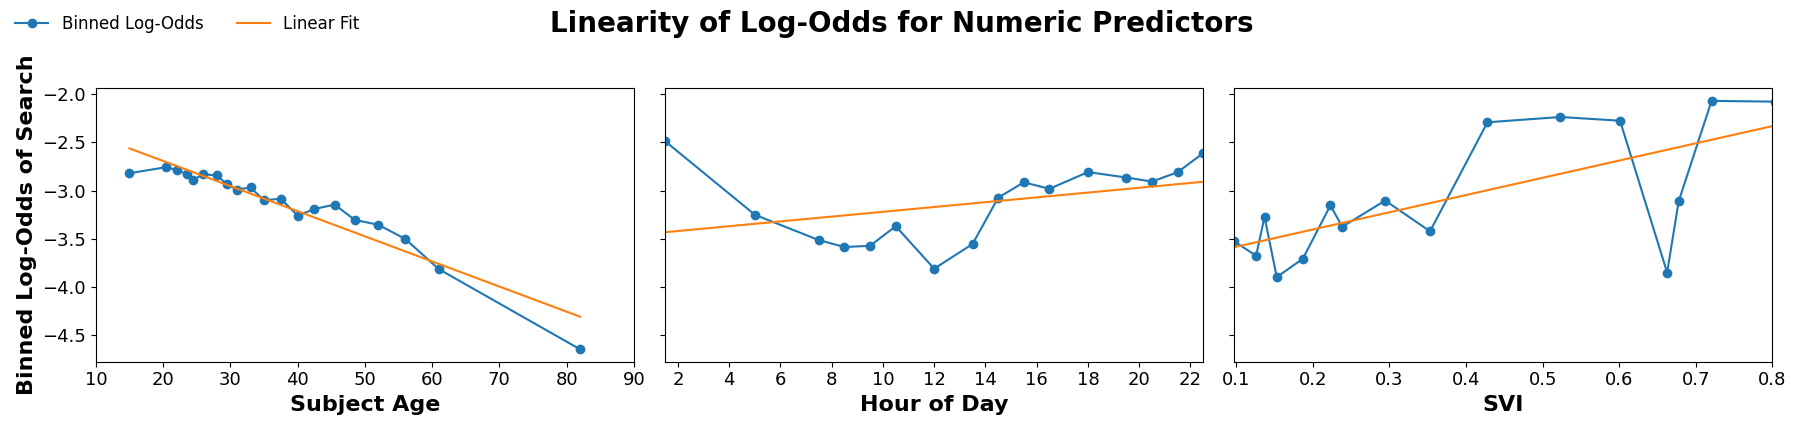

In [19]:
def binned_logit_plot(df, y_col, x_vars, n_bins=20, pretty=None,
                      title="Linearity of Log-Odds for Numeric Predictors",
                      figsize_per_var=6):
    """
    Create binned logit plots for numeric predictors to check linearity
    assumption for logistic regression.

    Parameters:
        df (pd.DataFrame): Dataframe containing predictors and outcome
        y_col (str): Binary outcome column
        x_vars (list): Numeric predictors to plot
        n_bins (int): Number of quantile bins
        pretty (dict): Optional mapping from column names to prettier labels
        title (str): Figure title
        figsize_per_var (float): Width per subplot

    Returns:
        None: Displays matplotlib figure
    """

    pretty = pretty or {}
    TITLE_FONTSIZE = 20
    SUBTITLE_FONTSIZE = 16
    AXIS_LABEL_FONTSIZE = 16
    TICK_FONTSIZE = 13
    LEGEND_FONTSIZE = 12

    def binned_logit_table(df, y_col, x_col, n_bins):
        tmp = df[[y_col, x_col]].copy()
        tmp["bin"] = pd.qcut(tmp[x_col], n_bins, duplicates="drop")
        g = tmp.groupby("bin")[y_col].agg(["mean", "size"]).reset_index()
        g["logit"] = np.log(g["mean"] / (1 - g["mean"]))
        g["x_mid"] = g["bin"].apply(lambda b: b.mid)
        return g[["x_mid", "mean", "logit", "size"]].sort_values("x_mid")

    fig, axes = plt.subplots(1, len(x_vars), figsize=(figsize_per_var * len(x_vars), 4), sharey=True)
    if len(x_vars) == 1:
        axes = [axes]

    for ax, x in zip(axes, x_vars):
        tbl = binned_logit_table(df, y_col, x, n_bins)

        # Plot binned logit
        ax.plot(tbl["x_mid"], tbl["logit"], marker="o", label="Binned Log-Odds")

        # Linear fit
        slope, intercept = np.polyfit(tbl["x_mid"], tbl["logit"], 1)
        xline = np.linspace(tbl["x_mid"].min(), tbl["x_mid"].max(), 200)
        ax.plot(xline, intercept + slope * xline, label="Linear Fit")

        # Axis labels
        ax.set_xlabel(pretty.get(x, x.replace("_", " ").title()),
                      fontweight="bold",
                      fontsize=AXIS_LABEL_FONTSIZE)

        # Ticks
        if x == "hour":
            ax.set_xticks(np.arange(0, 24, 2))
            ax.set_xlim(max(tbl["x_mid"].min(), -0.5), min(tbl["x_mid"].max(), 23.5))
        elif x == "subject_age":
            lo = int(np.floor(tbl["x_mid"].min() / 10) * 10)
            hi = int(np.ceil(tbl["x_mid"].max() / 10) * 10)
            ax.set_xticks(np.arange(lo, hi + 1, 10))
        elif x == "svi":
            ax.set_xticks(np.arange(0.0, 0.81, 0.1))
            ax.set_xlim(max(tbl["x_mid"].min(), 0.0), min(tbl["x_mid"].max(), 0.8))

        ax.tick_params(axis="both", labelsize=TICK_FONTSIZE)

    axes[0].set_ylabel("Binned Log-Odds of Search",
                       fontweight="bold",
                       fontsize=AXIS_LABEL_FONTSIZE)

    fig.suptitle(title,
                 fontsize=TITLE_FONTSIZE,
                 fontweight="bold",
                 y=1.05)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper left", ncol=2, fontsize=LEGEND_FONTSIZE, frameon=False)

    plt.tight_layout()
    plt.show()

# Usage
pretty = {"subject_age": "Subject Age", "hour": "Hour of Day", "svi": "SVI"}
x_vars = ["subject_age", "hour", "svi"]

binned_logit_plot(df, "search_conducted", x_vars, n_bins=20, pretty=pretty)

We can address the nonlinearity in the `hour` and `svi` variables in various ways. It may be the case that hourly data is too granular to make interpretations. As a result, we propose binning the hour into various interpretable categories, and treating it as a categorical variable for the logistic regression models. We define the following bins
* 12 AM - 6 AM: Late night and early morning hours. This is when most bars close and drunk drivers are on the road. This is also when people are typically most tired.
* 7 AM - 9 AM: This is when most people start waking up and heading to work. Similar people are on the road at these hours.
* 10 AM - 2 PM: This is when roads tend to be more empty. Those who are out may be leaving for lunch breaks.
* 3 PM - 5 PM: This is when many parents are picking their kids up from school. School zones are active and policing patterns may be different in these areas at this time.
* 6PM - 11 PM: This is when people are coming home from their daily activities, including work. Traffic is typically busiest around this time.

For the `svi` log-odds nonlinearity, we are unsure if this is due to discreteness. The amount of unique values is exactly equal to the number of policing zones. We will begin by fitting a linear term for the predictor.

#### Fit

In [20]:
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.metrics import (
    average_precision_score, roc_auc_score, accuracy_score,
    precision_score, recall_score, confusion_matrix
)
import numpy as np
import pandas as pd

def train_logistic_pipeline(df, y_col, num_features, cat_features,
                            race_order=None, sex_order=None, reason_order=None,
                            dow_order=None, hour_order=None,
                            test_size=0.15, val_size=0.15, seed=832,
                            Cs=[1e-3,1e-2,1e-1,1,10]):
    """
    Train a logistic regression pipeline with numeric scaling, categorical encoding,
    cross-validated hyperparameter tuning, and threshold optimization.

    Returns:
        dict: {
            'pipeline': trained Pipeline,
            'X_test': pd.DataFrame,
            'y_test': pd.Series,
            'test_probs': np.array,
            'test_pred': np.array,
            'threshold': float,
            'coef_table': pd.DataFrame
        }
    """

    np.random.seed(seed)

    # Bin hours if 'hour' exists
    if "hour" in df.columns:
        bins = [-0.5, 6.5, 9.5, 14.5, 17.5, 23.5]
        labels = ["12AM-6AM", "7AM-9AM", "10AM-2PM", "3PM-5PM", "6PM-11PM"]
        df["hour_bin"] = pd.cut(df["hour"], bins=bins, labels=labels)
        df["hour_bin"] = pd.Categorical(df["hour_bin"], categories=labels, ordered=True)
        cat_features = [c if c!="hour" else "hour_bin" for c in cat_features]

    # OneHotEncoder categories
    ohe = OneHotEncoder(
        categories=[race_order, sex_order, reason_order, dow_order, hour_order],
        drop="first",
        handle_unknown="ignore"
    )

    # Prepare X and y
    X = df[num_features + cat_features].copy()
    y = df[y_col].copy()

    # Split data: train / val / test
    test_ratio = test_size / (1 - val_size)  # because we split off val first
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=(val_size + test_size), stratify=y, random_state=seed
    )
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=seed
    )

    # Preprocessing
    preprocess = ColumnTransformer([
        ("num", StandardScaler(), num_features),
        ("cat", ohe, cat_features)
    ])

    # LogisticRegressionCV for tuning
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    tuned_lr = LogisticRegressionCV(
        Cs=Cs,
        cv=cv,
        scoring="average_precision",
        l1_ratios=(0,),  # Ridge (L2)
        solver="lbfgs",
        max_iter=2000,
        n_jobs=1,
        random_state=seed
    )

    pipeline = Pipeline([
        ("preprocess", preprocess),
        ("model", tuned_lr)
    ])

    pipeline.fit(X_train, y_train)

    # Validation predictions to tune threshold
    val_probs = pipeline.predict_proba(X_val)[:, 1]
    thresholds = np.linspace(0.01, 0.50, 100)
    best_thr, best_f1 = None, -1
    for thr in thresholds:
        pred = (val_probs >= thr).astype(int)
        prec = precision_score(y_val, pred, zero_division=0)
        rec = recall_score(y_val, pred, zero_division=0)
        f1 = 0 if (prec + rec) == 0 else 2*prec*rec/(prec+rec)
        if f1 > best_f1:
            best_f1, best_thr = f1, thr

    # Test set predictions
    test_probs = pipeline.predict_proba(X_test)[:, 1]
    test_pred = (test_probs >= best_thr).astype(int)

    # Coefficient table
    ohe_fit = pipeline.named_steps["preprocess"].named_transformers_["cat"]
    cat_names = ohe_fit.get_feature_names_out(cat_features)
    feature_names = np.concatenate([np.array(num_features), cat_names])
    coefs = pipeline.named_steps["model"].coef_.ravel()
    coef_table = pd.DataFrame({
        "feature": feature_names,
        "coef": coefs,
        "odds_ratio": np.exp(coefs),
        "abs_coef": np.abs(coefs)
    }).sort_values("abs_coef", ascending=False)

    return {
        "pipeline": pipeline,
        "X_test": X_test,
        "y_test": y_test,
        "test_probs": test_probs,
        "test_pred": test_pred,
        "threshold": best_thr,
        "coef_table": coef_table
    }

# Usage example
results = train_logistic_pipeline(
    df,
    y_col="search_conducted",
    num_features=["svi","subject_age"],
    cat_features=["subject_race","subject_sex","reason_for_stop","day_of_week","hour_bin"],
    race_order=["white","hispanic","black","asian/pacific islander","other"],
    sex_order=[0,1],
    reason_order=["Moving Violation", "Equipment Violation","Radio Call/Citizen Contact",
                  "Muni, County, H&S Code","Personal Knowledge/Informant",
                  "Suspect Info (I.S., Bulletin, Log)","Other"],
    dow_order=["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"],
    hour_order=["10AM-2PM","12AM-6AM","7AM-9AM","3PM-5PM","6PM-11PM"]
)

# Access results
print("Chosen threshold:", results["threshold"])
print("PR-AUC (test):", average_precision_score(results["y_test"], results["test_probs"]))
print(results["coef_table"].head(10))

/Users/asmit/Documents/SDS357/venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition period while keeping the deprecated behavior for the time being. The default value of use_legacy_attributes will change from True to False in scikit-learn 1.10. See the docstring of LogisticRegressionCV for more details.
  warnings.warn(


Chosen threshold: 0.10404040404040403
PR-AUC (test): 0.13679603165427756
                                              feature      coef  odds_ratio  \
10       reason_for_stop_Personal Knowledge/Informant  2.263226    9.614054   
8          reason_for_stop_Radio Call/Citizen Contact  2.099958    8.165826   
11  reason_for_stop_Suspect Info (I.S., Bulletin, ...  1.985919    7.285741   
9              reason_for_stop_Muni, County, H&S Code  1.686909    5.402755   
7                 reason_for_stop_Equipment Violation  0.829952    2.293208   
6                                       subject_sex_1  0.717507    2.049318   
3                                  subject_race_black  0.673164    1.960430   
5                                  subject_race_other -0.659026    0.517355   
19                                  hour_bin_12AM-6AM  0.648507    1.912683   
22                                  hour_bin_6PM-11PM  0.450333    1.568835   

    abs_coef  
10  2.263226  
8   2.099958  
11  1.985919

In [21]:
import numpy as np
import pandas as pd

def make_or_table(tuned_model, cat_features, num_features, custom_rows=None):
    """
    Build a readable Odds Ratio table from a fitted logistic regression pipeline.

    Parameters:
        tuned_model: sklearn Pipeline with 'preprocess' and 'model' steps
        cat_features: list of categorical feature names
        num_features: list of numeric feature names
        custom_rows: list of dicts with keys ['Feature','Feature_Key','Baseline','Note']
                     to define which features to include in table and baseline labels

    Returns:
        pd.DataFrame: Feature, Baseline, Odds Ratio, Interpretation
    """
    pre = tuned_model.named_steps["preprocess"]
    ohe = pre.named_transformers_["cat"]
    scaler = pre.named_transformers_["num"]

    # Feature names
    cat_names = ohe.get_feature_names_out(cat_features)
    feature_names = np.concatenate([np.array(num_features), cat_names])

    # Coefficients
    coefs = tuned_model.named_steps["model"].coef_.ravel()
    coef_map = dict(zip(feature_names, coefs))

    # Numeric scaling info
    num_scales = dict(zip(num_features, scaler.scale_))

    rows = []

    def add_row(feature_label, feature_key, baseline, note=""):
        beta = coef_map.get(feature_key)
        if beta is None:
            raise KeyError(f"Feature key '{feature_key}' not found in model coefficients")
        rows.append({
            "Feature": feature_label,
            "Baseline": baseline,
            "Coef (log-odds)": beta,
            "Odds Ratio": float(np.exp(beta)),
            "Interpretation": f"{np.exp(beta):.2f}× odds vs baseline" + (f" ({note})" if note else "")
        })

    if custom_rows is not None:
        for r in custom_rows:
            add_row(r["Feature"], r["Feature_Key"], r.get("Baseline","N/A"), r.get("Note",""))

    # Include numeric features (per 1 SD)
    for num in num_features:
        beta = coef_map[num]
        rows.append({
            "Feature": num,
            "Baseline": "N/A",
            "Coef (log-odds)": beta,
            "Odds Ratio": float(np.exp(beta)),
            "Interpretation": f"{np.exp(beta):.2f}× odds per +1 SD in {num} (SD={num_scales[num]:.3f})"
        })

    out = pd.DataFrame(rows)

    # Formatting
    out["Coef (log-odds)"] = out["Coef (log-odds)"].map(lambda x: f"{x:.3f}")
    out["Odds Ratio"] = out["Odds Ratio"].map(lambda x: f"{x:.2f}")

    return out[["Feature","Baseline","Odds Ratio","Interpretation"]]

custom_rows = [
    {"Feature": "Reason for Stop: Personal Knowledge/Informant",
     "Feature_Key": "reason_for_stop_Personal Knowledge/Informant",
     "Baseline": "Moving Violation"},
    {"Feature": "Subject Sex: Male",
     "Feature_Key": "subject_sex_1",
     "Baseline": "Female"},
    {"Feature": "Subject Race: Black",
     "Feature_Key": "subject_race_black",
     "Baseline": "White"},
    {"Feature": "Time of Stop: 12AM–6AM",
     "Feature_Key": "hour_bin_12AM-6AM",
     "Baseline": "10AM–2PM"},
]

or_table = make_or_table(results["pipeline"], cat_features=["subject_race","subject_sex","reason_for_stop","day_of_week","hour_bin"],num_features=["svi","subject_age"],
                         custom_rows=custom_rows)
or_table

,Feature,Baseline,Odds Ratio,Interpretation
0,Reason for Stop: Personal Knowledge/Informant,Moving Violation,9.61,9.61× odds vs baseline
1,Subject Sex: Male,Female,2.05,2.05× odds vs baseline
2,Subject Race: Black,White,1.96,1.96× odds vs baseline
3,Time of Stop: 12AM–6AM,10AM–2PM,1.91,1.91× odds vs baseline
4,svi,N/A,1.32,1.32× odds per +1 SD in svi (SD=0.233)
5,subject_age,N/A,0.79,0.79× odds per +1 SD in subject_age (SD=14.210)


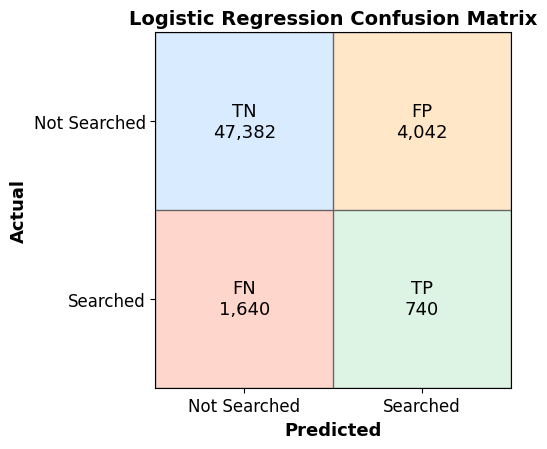

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(y_true, y_pred, labels=["Not Searched", "Searched"],
                          cmap_colors=None, title="Logistic Regression Confusion Matrix"):
    """
    Plot a binary confusion matrix with counts and custom pastel colors.
    """
    cm = confusion_matrix(y_true, y_pred)

    if cmap_colors is None:
        cmap_colors = {
            "TN": "#D9ECFF",  # soft blue
            "FP": "#FFE7C7",  # soft orange
            "FN": "#FFD6CC",  # soft red
            "TP": "#DDF3E3"   # soft green
        }

    # Arrange cell color indices
    color_map_array = np.array([[0, 1], [2, 3]])
    cmap = ListedColormap([cmap_colors[k] for k in ["TN", "FP", "FN", "TP"]])

    fig, ax = plt.subplots(figsize=(5.8, 4.6))
    ax.imshow(color_map_array, cmap=cmap, vmin=0, vmax=3)

    # Set ticks and labels
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(labels, fontsize=12)
    ax.set_yticklabels(labels, fontsize=12)
    ax.set_xlabel("Predicted", fontweight="bold", fontsize=13)
    ax.set_ylabel("Actual", fontweight="bold", fontsize=13)
    ax.set_title(title, fontweight="bold", fontsize=14)

    # Add gridlines
    ax.set_xticks(np.arange(-.5, 2, 1), minor=True)
    ax.set_yticks(np.arange(-.5, 2, 1), minor=True)
    ax.grid(which="minor", color="#666666", linestyle="-", linewidth=1)
    ax.tick_params(which="minor", bottom=False, left=False)

    # Annotate cells with TN, FP, FN, TP + counts
    label_matrix = np.array([["TN", "FP"], ["FN", "TP"]])
    for (i, j), val in np.ndenumerate(cm):
        ax.text(j, i, f"{label_matrix[i,j]}\n{val:,}",
                ha="center", va="center", fontsize=13)

    plt.tight_layout()
    plt.show()

# Usage
plot_confusion_matrix(results['y_test'], results['test_pred'])

We will break down the results into a few steps. To begin, observe that our scoring function for cross-validation is Precision-Recall Area Under the Curve (PR-AUC). This is because the outcome is rare, so ROC-AUC and accuracy can fail to capture Type I and Type II error rates. If we randomly ranked each stop, then the PR_AUC would be close to the prevalence of searches in the data set (roughly $4.4%$).

Our final ROC-AUC is moderately high, which is slightly misleading. The final model has a PR_AUC that is roughly three times the prevalence. Hence, the logistic regression model does not entirely seem to fail to learn about the data.

When tuning the threshold to maximize F1 score (chosen due to the rare outcome), we found that a much smaller threshold for positive prediction ($0.0842$, rather than $0.5$) worked best.

Finally, we will look at the largest coefficients in magnitude to gauge feature importance. The interpretation of each (categorical) coefficient $\beta_j$ is that subjects who happen to have $\beta_j$ as their $j$-th covariate are associated with a likelihood of search that is $e^{\beta_j}$ times higher odds of search than the baseline.

With this interpretation in mind, our logistic regression model appears to have identified a few things. Firstly, the most important factors in increasing the likelihood of a search are based on information tips to SDPD. This aligns with a well-functioning searching policy. Notably, being stopped for a moving violation appears to be associated with a decrease in the likelihood of being searched by approximately $53\%$

However, there also appear to be other factors which appear to be unrelated to information tips. For example, those who live in service area 710 appear to be associated with a approximately $63\%$ lower likelihood of being searched. The most prominent demographic factors that are associated with an increase in the likelihood of being searched include being black or hispanic, as well as being a male. Finally, being stopped between the hours of 12 AM to 6 PM, inclusive appear to be associated with an increase in the same likelihood.

In [25]:
ohe = results['pipeline'].named_steps["preprocess"].named_transformers_["cat"]
for feat, cats in zip(["subject_race","subject_sex","reason_for_stop","day_of_week","hour_bin"], ohe.categories_):
    print(feat, "baseline (dropped):", cats[0])

subject_race baseline (dropped): white
subject_sex baseline (dropped): 0
reason_for_stop baseline (dropped): Moving Violation
day_of_week baseline (dropped): Monday
hour_bin baseline (dropped): 10AM-2PM


# Next Steps for Modeling:

### XGBoost

We will use decision trees as the weak learner for this model. This is because there is a natural hierarchical interpretation to the model fit. This can help provide a benchmark for our more classical models. As with other models, we do still assume that the data are i.i.d. We also need to scale the features to avoid artificial dominant directions caused by natural differences in scales of the predictors.

Similarly, we also require that sample sizes are not small (which can destabilize the gradient descent), though this is not as much of a concern due to the large amount of data we have retained thus far.

Gradient boosting requires that the covariates are numeric. To ensure this, we will encode all categorical variables into dummies using one-hot encoding.

Imports

In [ ]:
import numpy as np
import pandas as pd
import xgboost as xgb

from pathlib import Path
import sys

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import (
    precision_score, recall_score, average_precision_score,
    roc_auc_score, accuracy_score
)

Load and prepare data

In [8]:
# Load data
df = pd.read_csv(Path(FINAL_DATA_PATH) / "post_eda_df.csv")

SEED = 832

# Feature setup
num_features = ["svi", "subject_age", "hour"]
cat_features = ["subject_race", "subject_sex", "reason_for_stop", "day_of_week"]
y_col = "search_conducted"

X = df[num_features + cat_features].copy()
y = df[y_col].copy()

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=SEED
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED
)

print("Prevalence:", y.mean(), "Train:", y_train.mean(), "Val:", y_val.mean(), "Test:", y_test.mean())

Prevalence: 0.04423318185619895 Train: 0.044232385306850724 Val: 0.044235451554746015 Test: 0.04423462939558397


One hot encoding

In [9]:
ohe = OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False)

X_train_cat = ohe.fit_transform(X_train[cat_features])
X_val_cat   = ohe.transform(X_val[cat_features])
X_test_cat  = ohe.transform(X_test[cat_features])

X_train_enc = np.hstack([X_train[num_features].to_numpy(), X_train_cat])
X_val_enc   = np.hstack([X_val[num_features].to_numpy(),   X_val_cat])
X_test_enc  = np.hstack([X_test[num_features].to_numpy(),  X_test_cat])

feature_names = list(num_features) + list(ohe.get_feature_names_out(cat_features))

Tuning + class imbalance handling

In [10]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print("scale_pos_weight:", scale_pos_weight)

xgb_base = xgb.XGBClassifier(
    objective="binary:logistic",
    scale_pos_weight=scale_pos_weight,
    random_state=SEED,
    eval_metric="aucpr",
    tree_method="hist",
)

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [3, 4],
    "learning_rate": [0.05, 0.1],
}

grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring="average_precision",   # PR-AUC
    cv=2,                          # speed
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train_enc, y_train)

print("Best params:", grid_search.best_params_)
print("Best CV PR-AUC:", grid_search.best_score_)

scale_pos_weight: 21.607869620025212
Fitting 2 folds for each of 8 candidates, totalling 16 fits
Best params: {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 200}
Best CV PR-AUC: 0.14378275209606212


Final model

In [11]:
best_params = grid_search.best_params_

xgb_model = xgb.XGBClassifier(
    **best_params,
    objective="binary:logistic",
    scale_pos_weight=scale_pos_weight,
    random_state=SEED,
    eval_metric="aucpr",
    tree_method="hist",
)

xgb_model.fit(X_train_enc, y_train)

# Threshold tuning on validation (maximize F1)
val_probs = xgb_model.predict_proba(X_val_enc)[:, 1]
thresholds = np.linspace(0.01, 0.50, 100)

best_thr, best_f1 = None, -1
for thr in thresholds:
    pred = (val_probs >= thr).astype(int)
    prec = precision_score(y_val, pred, zero_division=0)
    rec  = recall_score(y_val, pred, zero_division=0)
    f1 = 0 if (prec + rec) == 0 else 2 * prec * rec / (prec + rec)
    if f1 > best_f1:
        best_f1, best_thr = f1, thr

# Test evaluation
test_probs = xgb_model.predict_proba(X_test_enc)[:, 1]
test_pred  = (test_probs >= best_thr).astype(int)

print("\nChosen threshold:", round(best_thr, 4), "Val F1:", round(best_f1, 4))
print("PR-AUC (test):", average_precision_score(y_test, test_probs))
print("ROC-AUC (test):", roc_auc_score(y_test, test_probs))
print("Accuracy (test):", accuracy_score(y_test, test_pred))
print("Precision (test):", precision_score(y_test, test_pred, zero_division=0))
print("Recall (test):", recall_score(y_test, test_pred, zero_division=0))


Chosen threshold: 0.5 Val F1: 0.1773
PR-AUC (test): 0.15142118629320908
ROC-AUC (test): 0.7776399160317518
Accuracy (test): 0.7068991153074121
Precision (test): 0.10082279990460291
Recall (test): 0.7105042016806723


Interpretability: SHAP

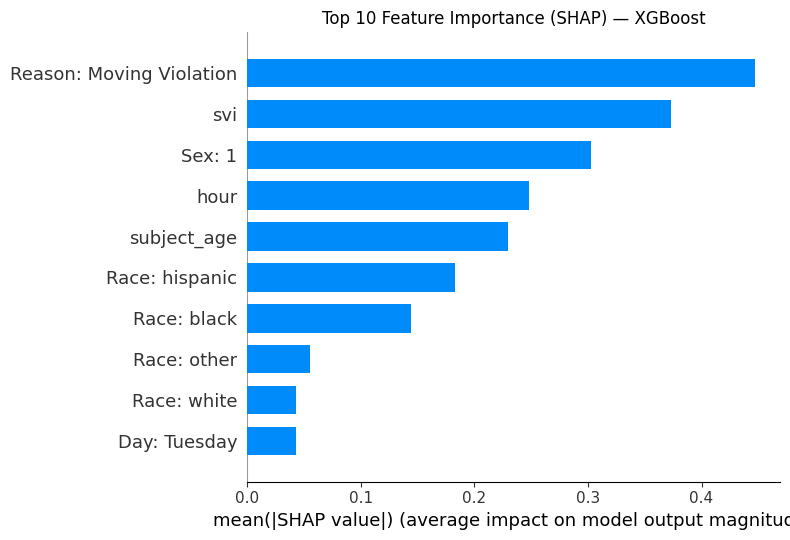

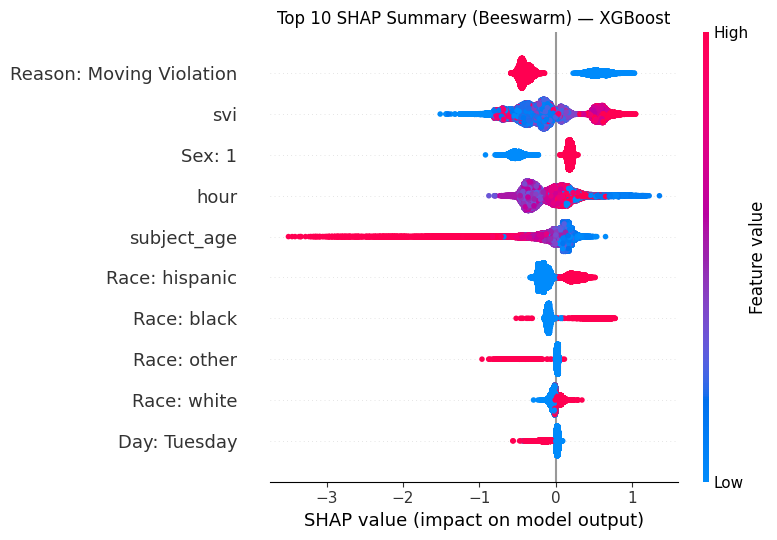

In [14]:
import shap
import matplotlib.pyplot as plt

X_test_df = pd.DataFrame(X_test_enc, columns=feature_names)

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_df)

# Top 10 mean |SHAP|
mean_abs = np.abs(shap_values).mean(axis=0)
top_n = 10
top_idx = np.argsort(mean_abs)[-top_n:]
X_top = X_test_df.iloc[:, top_idx]

def clean_name(name: str) -> str:
    return (name.replace("reason_for_stop_", "Reason: ")
                .replace("subject_race_", "Race: ")
                .replace("subject_sex_", "Sex: ")
                .replace("day_of_week_", "Day: "))

X_top = X_top.rename(columns=clean_name)

# Bar importance
shap.summary_plot(shap_values[:, top_idx], X_top, plot_type="bar", show=False)
plt.title("Top 10 Feature Importance (SHAP) — XGBoost")
plt.tight_layout()
plt.show()

# Beeswarm
shap.summary_plot(shap_values[:, top_idx], X_top, show=False)
plt.title("Top 10 SHAP Summary (Beeswarm) — XGBoost")
plt.tight_layout()
plt.show()

Interpretation: confusion matrix

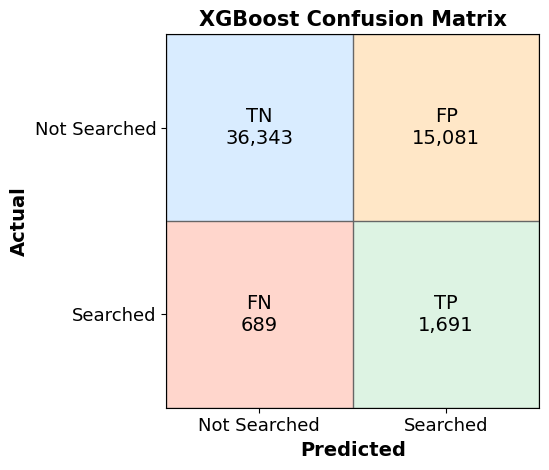

In [25]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# predicted labels using chosen threshold
test_pred = (test_probs >= best_thr).astype(int)

cm = confusion_matrix(y_test, test_pred) 

TN_COLOR = "#D9ECFF"  # soft blue
FP_COLOR = "#FFE7C7"  # soft orange
FN_COLOR = "#FFD6CC"  # soft vermillion/red
TP_COLOR = "#DDF3E3"  # soft green

cell_colors = np.array([[0, 1],
                        [2, 3]])
cmap = ListedColormap([TN_COLOR, FP_COLOR, FN_COLOR, TP_COLOR])

fig, ax = plt.subplots(figsize=(6.2, 4.8))
ax.imshow(cell_colors, cmap=cmap, vmin=0, vmax=3)

# Labels
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Not Searched", "Searched"], fontsize=13)
ax.set_yticklabels(["Not Searched", "Searched"], fontsize=13)
ax.set_xlabel("Predicted", fontweight="bold", fontsize=14)
ax.set_ylabel("Actual", fontweight="bold", fontsize=14)
ax.set_title("XGBoost Confusion Matrix", fontweight="bold", fontsize=15)

# Grid lines between cells
ax.set_xticks(np.arange(-.5, 2, 1), minor=True)
ax.set_yticks(np.arange(-.5, 2, 1), minor=True)
ax.grid(which="minor", color="#666666", linestyle="-", linewidth=1)
ax.tick_params(which="minor", bottom=False, left=False)

# Annotate cells
labels = np.array([["TN", "FP"], ["FN", "TP"]])
for (i, j), val in np.ndenumerate(cm):
    ax.text(j, i, f"{labels[i,j]}\n{val:,}", ha="center", va="center",
            fontsize=14)

plt.tight_layout()
plt.show()